**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 7**
Análisis de Componentes Principales (PCA)

---

*   NOMBRE: Felipe de Jesus Gamez Castellanos
*   MATRÍCULA: A01797817

*   NOMBRE: Carlos Humberto Galvan Perales
*   MATRÍCULA: A01797969

*   NOMBRE: Ernesto García González
*   MATRÍCULA: A00827434

*   NOMBRE: Miguel Fernndo Garcia Pina
*   MATRÍCULA: A01046823


En esta actividad trabajarás con el archivo `automobile_dataset.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de automóviles, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar diferentes aspectos de los vehículos y sus precios, e incluyen información sobre el fabricante, tipo de motor, dimensiones, peso, rendimiento de combustible y otras especificaciones técnicas. Los indicadores incluidos son:

* `symboling`: Nivel de riesgo del seguro del automóvil, de -3 (bajo riesgo) a +3 (alto riesgo)
* `normalized_losses`: Pérdidas normalizadas del seguro (valor numérico de la aseguradora, algunas veces faltante)
* `make`: Marca del automóvil (por ejemplo, Audi, BMW, Honda)
* `fuel_type`: Tipo de combustible (gasolina o diésel)
* `aspiration`: Tipo de aspiración del motor (normal o turbo)
* `num_doors`: Número de puertas del automóvil (dos o cuatro)
* `body_style`: Estilo de carrocería (sedán, hatchback, wagon, hardtop, convertible)
* `drive_wheels`: Tipo de tracción (fwd: delantera, rwd: trasera, 4wd: en las cuatro ruedas)
* `engine_location`: Ubicación del motor (delantero o trasero)
* `wheel_base`: Distancia entre ejes (en pulgadas)
* `length`: Largo total del automóvil (en pulgadas)
* `width`: Ancho total del automóvil (en pulgadas)
* `height`: Altura total del automóvil (en pulgadas)
* `curb_weight`: Peso del automóvil sin carga (en libras)
* `engine_type`: Tipo de motor (OHV, OHC, DOHC, etc.)
* `num_cylinders`: Número de cilindros del motor
* `engine_size`: Tamaño del motor (en cc)
* `fuel_system`: Sistema de combustible (por ejemplo, mpfi, 2bbl, 4bbl)
* `bore`: Diámetro del cilindro (en pulgadas)
* `stroke`: Carrera del pistón (en pulgadas)
* `compression_ratio`: Relación de compresión del motor
* `horsepower`: Potencia del motor (en caballos de fuerza)
* `peak_rpm`: Revoluciones máximas por minuto
* `city_mpg`: Rendimiento de combustible en ciudad (millas por galón)
* `highway_mpg`: Rendimiento de combustible en carretera (millas por galón)
* `price`: Precio del automóvil (en dólares estadounidenses) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

1. Descarga el archivo: `automobile_dataset.csv` y guarda, en un dataframe (`cars_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
    **17 Numeriacas , 9 En texto**


* Al revisar los primeros registros, notarás que la columna `normalized_losses` contiene el símbolo `?`. Esto sugiere que se utilizó para indicar valores faltantes. Identifica todas las columnas que presentan este símbolo.

* Sustituye el símbolo `?` por valores faltantes (`NaN`) y convierte las columnas al tipo de dato adecuado. Esto es necesario porque la presencia del símbolo pudo haber hecho que pandas las interpretara como object, aunque en realidad no lo fueran.

In [2]:
# Cargar el dataset
cars_df = pd.read_csv('automobile_dataset.csv')

# Utiliza el método info() para obtener el resumen
cars_df.info()

# 3a. Identificar columnas con el símbolo '?'
print("\n--- Identificando columnas con '?' ---")
cols_with_question_mark = cars_df.columns[cars_df.isin(['?']).any()].tolist()
print(f"Columnas que contienen el símbolo '?': {cols_with_question_mark}")

# 3b. Sustituir '?' por valores faltantes (NaN)
cars_df.replace('?', np.nan, inplace=True)
print("\nSímbolo '?' reemplazado por NaN.")

# 3c. Convertir columnas al tipo de dato adecuado (numérico)
cols_to_convert_numeric = [
    'normalized_losses',
    'bore',
    'stroke',
    'horsepower',
    'peak_rpm',
    'price'
]

for col in cols_to_convert_numeric:
    # pd.to_numeric convierte la columna a float o int
    cars_df[col] = pd.to_numeric(cars_df[col])

print(f"Columnas {cols_to_convert_numeric} convertidas a tipo numérico.")
print("\n--- Resumen final de tipos de datos (Después de la limpieza) ---")
cars_df.info()

print("\n--- Primeros 5 registros (Después de la limpieza) ---")
# Vemos que los '?' ahora son 'NaN'
print(cars_df.head())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non

# Análisis exploratorio de datos (univariado)

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados e imprime el porcentaje de faltantes por columna.
* Obtén las estadísticas descriptivas, separado las numéricas (incluye asimetría y curtosis) y las categóricas (incluye tablas de frecuencias).
* Genera histogramas para las numéricas y diagramas de barras para las categóricas.

In [3]:
# 1. Verificar valores duplicados
num_duplicados = cars_df.duplicated().sum()
print(f"Número de filas duplicadas encontradas: {num_duplicados}")

# 2. Porcentaje de faltantes por columna
porcentaje_faltantes = (cars_df.isnull().sum() / len(cars_df)) * 100
# Ordenamos de mayor a menor para ver las columnas más problemáticas primero
print(porcentaje_faltantes.sort_values(ascending=False))



print("--- Estadísticas Descriptivas (Numéricas) ---")
# Seleccionar solo columnas numéricas
df_numeric = cars_df.select_dtypes(include=np.number)

# Obtener estadísticas descriptivas básicas
numeric_stats = df_numeric.describe()

# Añadir asimetría (skewness) y curtosis (kurtosis)
numeric_stats.loc['skew'] = df_numeric.skew()
numeric_stats.loc['kurtosis'] = df_numeric.kurt()
print(numeric_stats.T)


print("--- Estadísticas Descriptivas (Categóricas) ---")
# Seleccionar solo columnas de texto/objeto
df_categorical = cars_df.select_dtypes(include='object')

# 1. Resumen categórico (count, unique, top, freq)
print(df_categorical.describe().T)

# 2. Tablas de frecuencias para cada columna categórica
print("\n--- Tablas de Frecuencia (Categóricas) ---")
for col in df_categorical.columns:
    print(f"\nFrecuencia para: {col}")
    print(df_categorical[col].value_counts())
    print("-" * 30)




Número de filas duplicadas encontradas: 0
normalized_losses    20.00000
stroke                1.95122
price                 1.95122
bore                  1.95122
horsepower            0.97561
peak_rpm              0.97561
make                  0.00000
fuel_type             0.00000
aspiration            0.00000
symboling             0.00000
wheel_base            0.00000
engine_location       0.00000
drive_wheels          0.00000
body_style            0.00000
num_doors             0.00000
length                0.00000
height                0.00000
width                 0.00000
fuel_system           0.00000
engine_size           0.00000
num_cylinders         0.00000
engine_type           0.00000
curb_weight           0.00000
compression_ratio     0.00000
city_mpg              0.00000
highway_mpg           0.00000
dtype: float64
--- Estadísticas Descriptivas (Numéricas) ---
                   count          mean          std      min      25%  \
symboling          205.0      0.834146     1

Generando histogramas para variables numéricas...


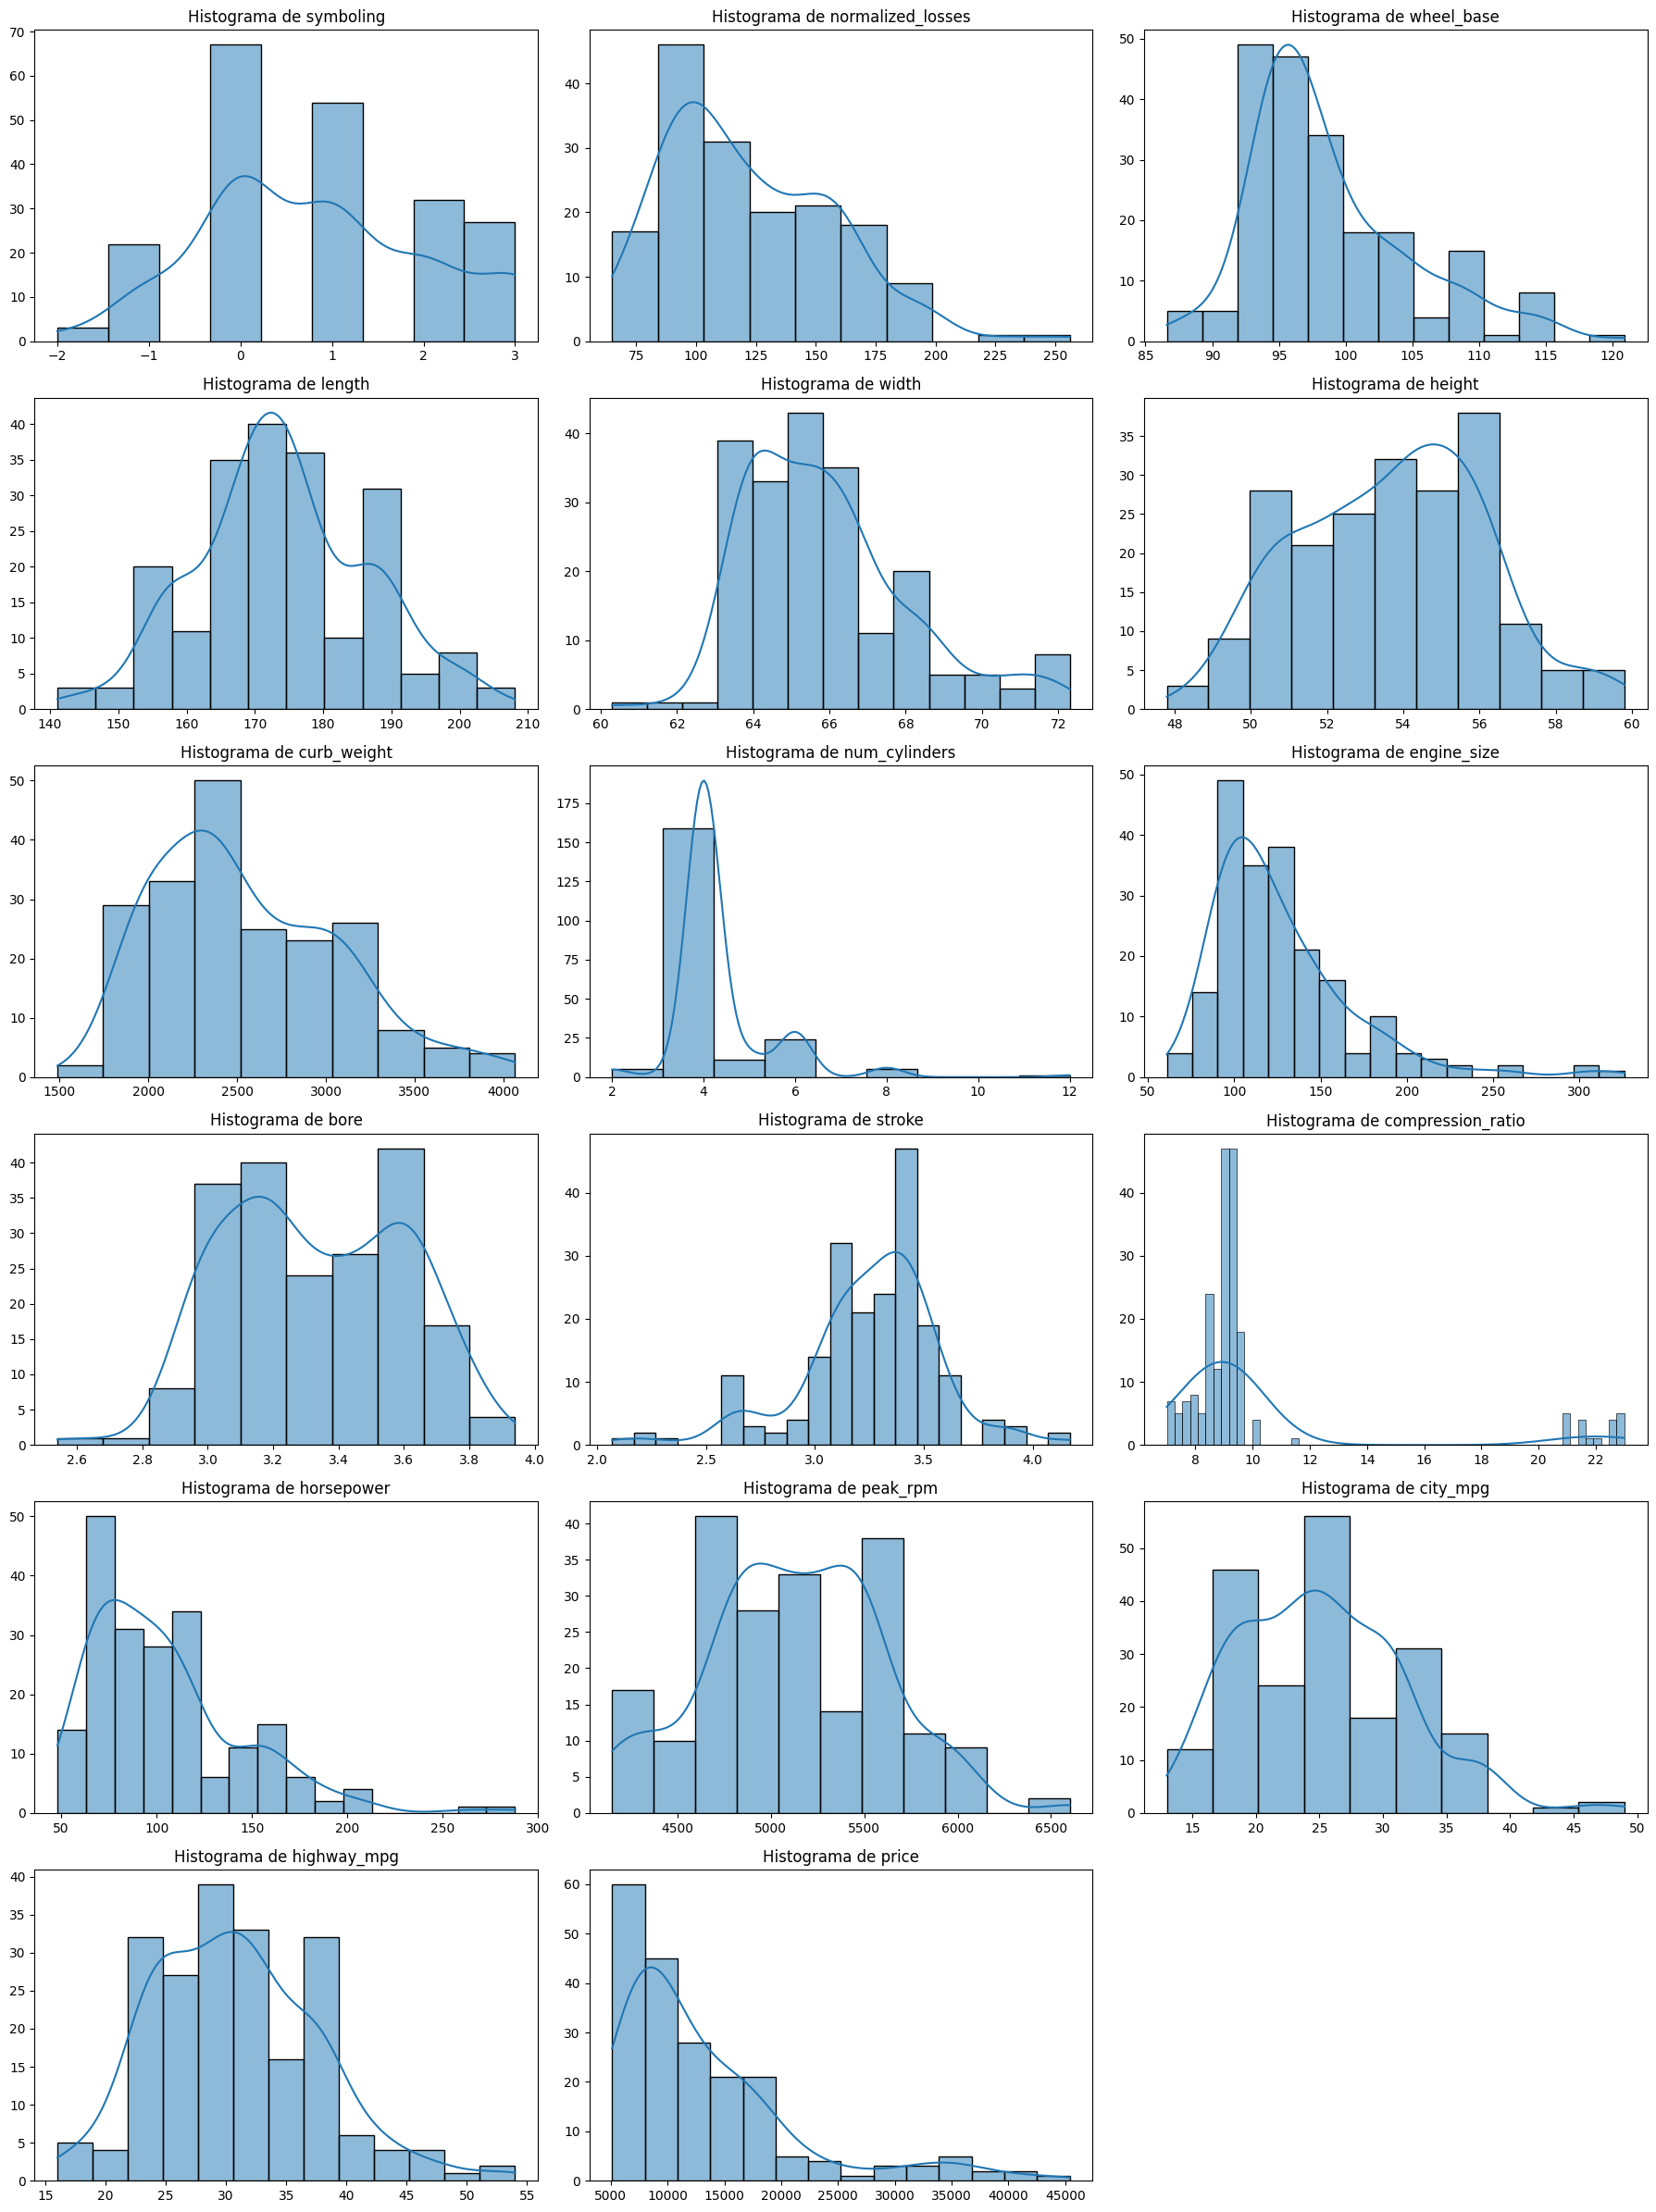

In [4]:
print("Generando histogramas para variables numéricas...")

numeric_cols = cars_df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=cars_df,
        x=col,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Histograma de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

Generando diagramas de barras para variables categóricas...


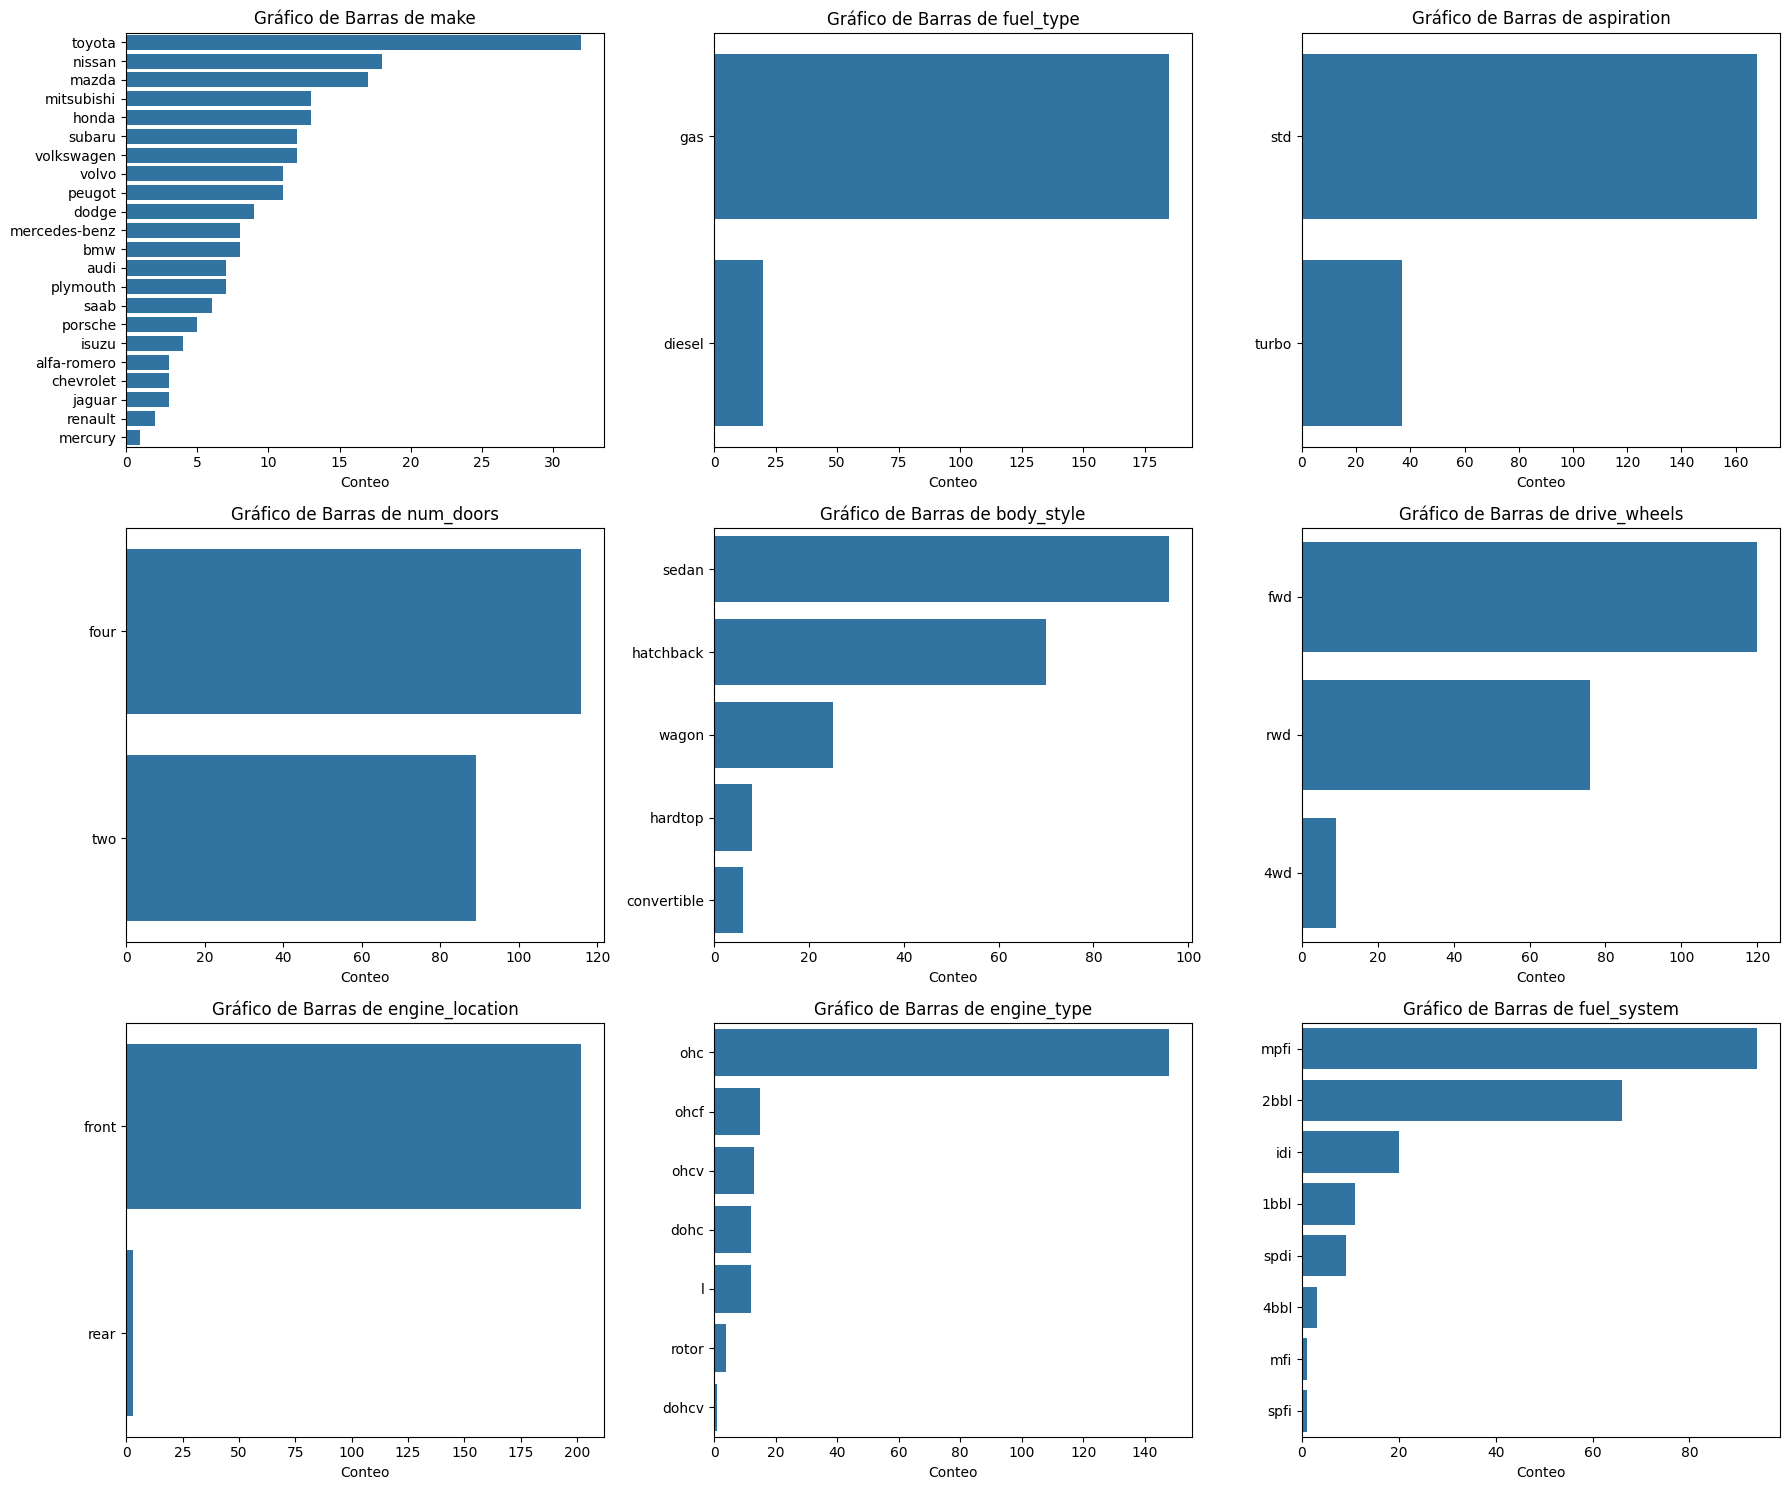

In [5]:
print("Generando diagramas de barras para variables categóricas...")

categorical_cols = cars_df.select_dtypes(include='object').columns
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=cars_df,
        y=col,
        ax=axes[i],
        order=cars_df[col].value_counts().index
    )
    axes[i].set_title(f'Gráfico de Barras de {col}', fontsize=12)
    axes[i].set_xlabel('Conteo')
    axes[i].set_ylabel('')
plt.tight_layout()

# Análisis exploratorio de datos (bivariado)

3. Genera algunos gráficos bivariados para familiarizarte con el conjunto de datos:
* Gráfico de barras apiladas normalizadas que muestra la distribución de los tipos de tracción para cada fabricante.
* Diagrama de cajas para visualizar cómo se distribuye el precio de los automóviles según el estilo de carrocería. Esto permitirá comparar la mediana, los cuartiles y la presencia de valores atípicos entre los diferentes tipos de carrocería.
* Gráfico de barras que muestre los 10 automóviles más caros, ordenados de mayor a menor precio, con cada barra diferenciada por fabricante.
* Diagrama de dispersión para explorar la relación entre el tamaño del motor y el precio de los automóviles. Diferencia con colores los puntos según el tipo de aspiración y con el tamaño de los puntos el número de puertas.

**Nota.** Debes incluir en cada gráfico una conclusión de lo observado.

Generando Gráfico 1: Barras Apiladas (Tracción por Fabricante)...


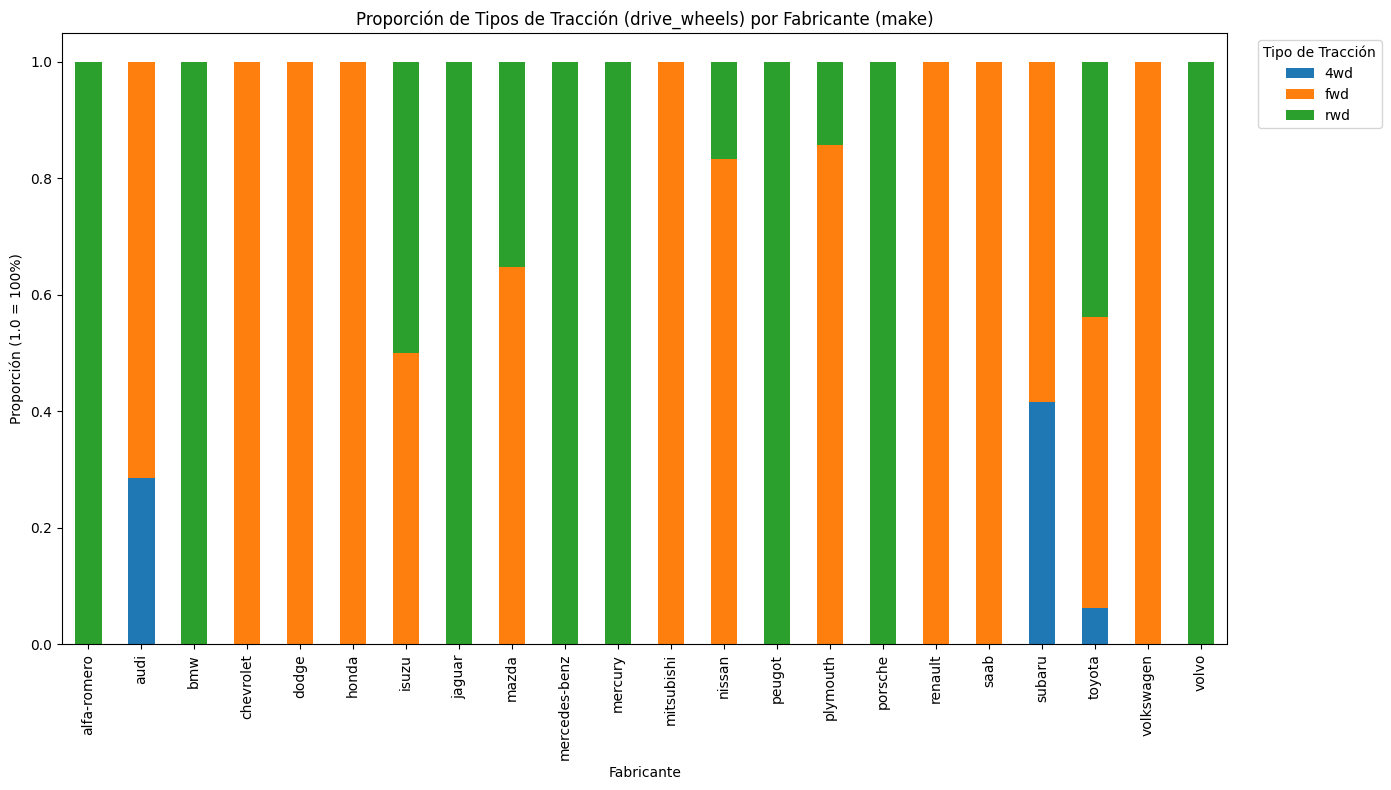

In [6]:

print("Generando Gráfico 1: Barras Apiladas (Tracción por Fabricante)...")


crosstab_df = pd.crosstab(cars_df['make'], cars_df['drive_wheels'])
crosstab_norm = crosstab_df.div(crosstab_df.sum(axis=1), axis=0)
ax = crosstab_norm.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    title='Proporción de Tipos de Tracción (drive_wheels) por Fabricante (make)'
)

ax.set_xlabel("Fabricante")
ax.set_ylabel("Proporción (1.0 = 100%)")
ax.legend(title='Tipo de Tracción', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()


Generando Gráfico 2: Diagrama de Cajas (Precio por Estilo)...


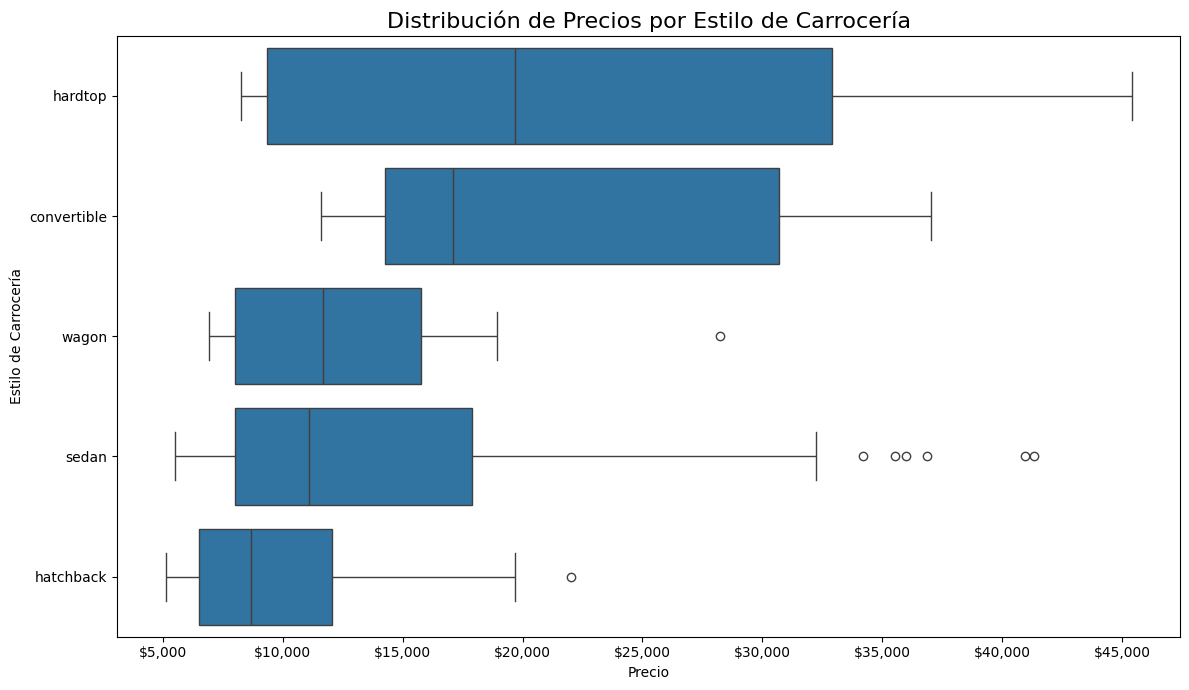

In [7]:
print("Generando Gráfico 2: Diagrama de Cajas (Precio por Estilo)...")

median_prices = cars_df.groupby('body_style')['price'].median().sort_values(ascending=False).index
plt.figure(figsize=(12, 7))
ax = sns.boxplot(
    data=cars_df,
    x='price',
    y='body_style',
    order=median_prices
)

ax.set_title('Distribución de Precios por Estilo de Carrocería', fontsize=16)
ax.set_xlabel("Precio")
ax.set_ylabel("Estilo de Carrocería")
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

plt.tight_layout()

Generando Gráfico 3: Barras (Top 10 Autos Más Caros)...


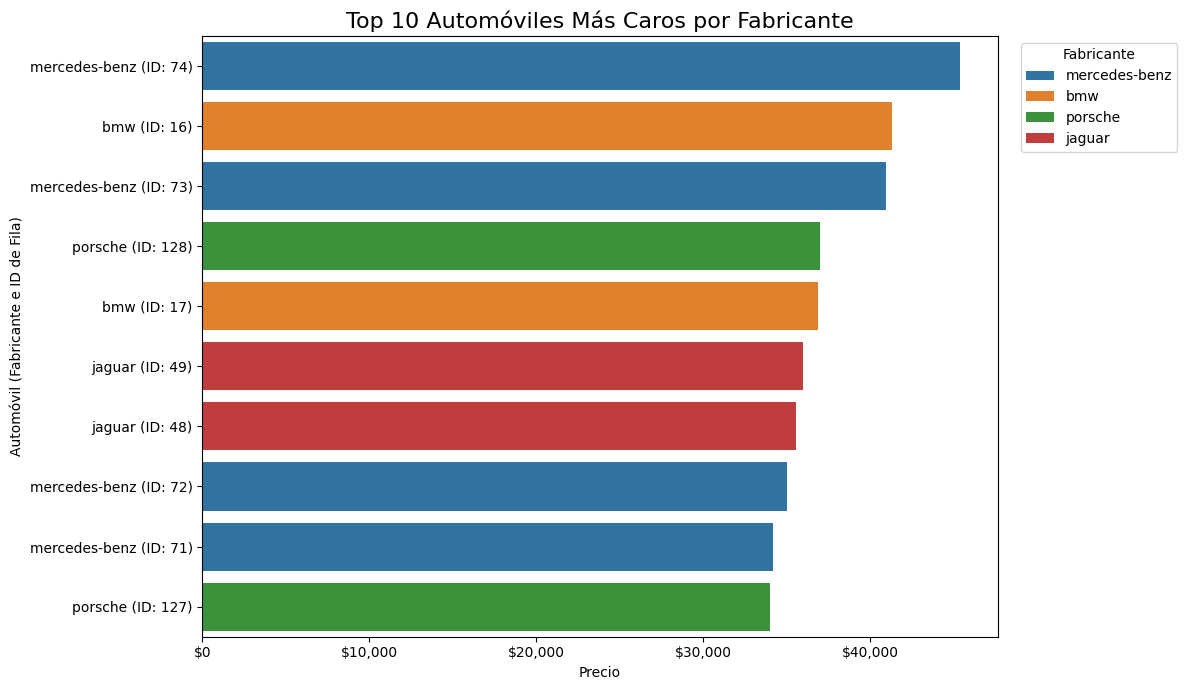

In [8]:
print("Generando Gráfico 3: Barras (Top 10 Autos Más Caros)...")

top_10_cars = cars_df.nlargest(10, 'price').sort_values('price', ascending=False)
top_10_cars['label'] = top_10_cars['make'] + ' (ID: ' + top_10_cars.index.astype(str) + ')'

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=top_10_cars,
    x='price',
    y='label',
    hue='make',
    dodge=False
)

ax.set_title('Top 10 Automóviles Más Caros por Fabricante', fontsize=16)
ax.set_xlabel("Precio")
ax.set_ylabel("Automóvil (Fabricante e ID de Fila)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

ax.legend(title='Fabricante', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()

Generando Gráfico 4: Dispersión (Motor vs Precio)...


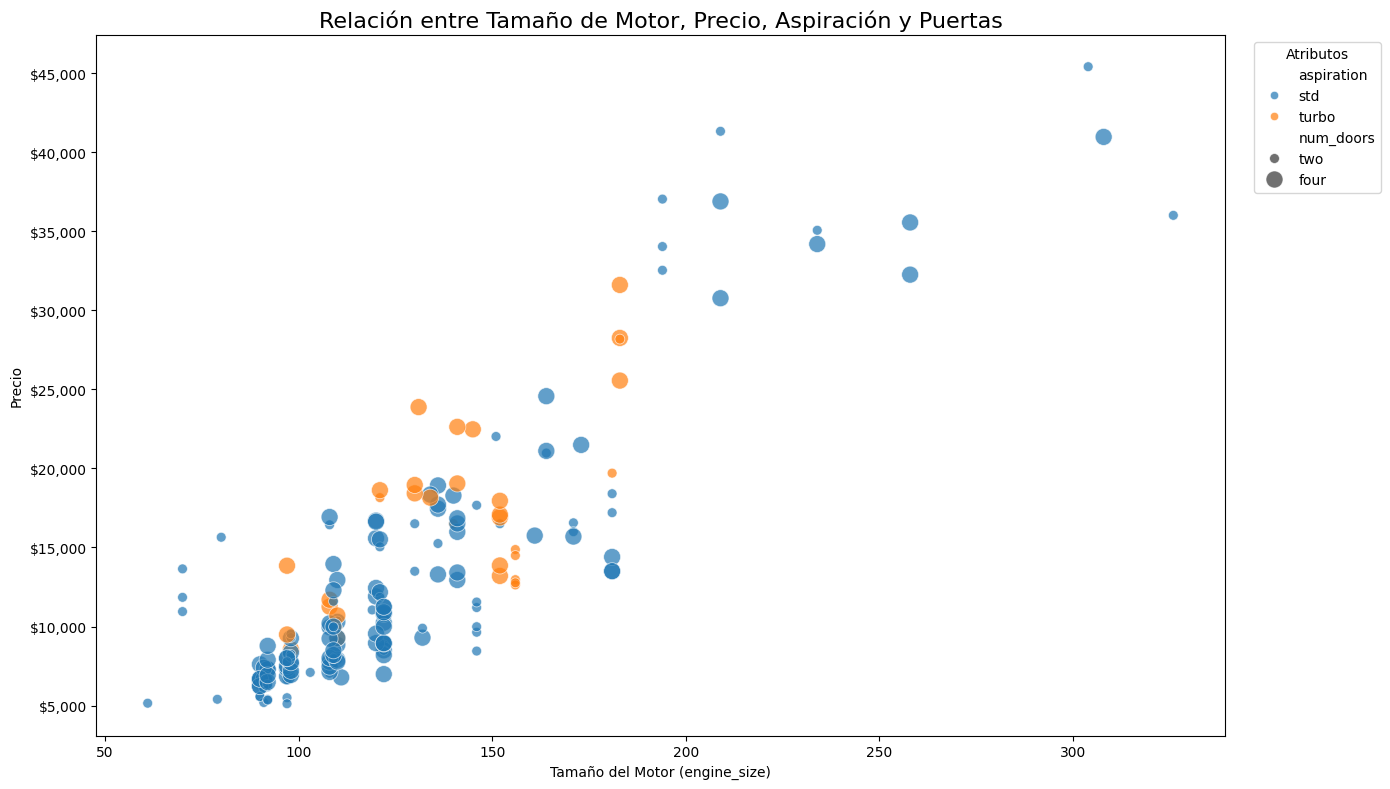

In [9]:
print("Generando Gráfico 4: Dispersión (Motor vs Precio)...")

plt.figure(figsize=(14, 8))
ax = sns.scatterplot(
    data=cars_df,
    x='engine_size',
    y='price',
    hue='aspiration',
    size='num_doors',
    sizes={'two': 50, 'four': 150},
    alpha=0.7
)

ax.set_title('Relación entre Tamaño de Motor, Precio, Aspiración y Puertas', fontsize=16)
ax.set_xlabel("Tamaño del Motor (engine_size)")
ax.set_ylabel("Precio")
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'${y:,.0f}'))
ax.legend(title='Atributos', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()



4. Genera un mapa de calor de la matriz de correlación entre las variables numéricas del conjunto de datos, mostrando los valores de correlación en cada celda.
* ¿Cuáles son las tres variables más correlacionadas con el precio?

*Top 3 Variables Más Correlacionadas con 'price'*


1.  engine_size    0.872335
2.  curb_weight    0.834415
3.  horsepower     0.810533

Generando Gráfico 5: Mapa de Calor de Correlación...

--- Top 3 Variables Más Correlacionadas con 'price' ---
engine_size    0.872335
curb_weight    0.834415
horsepower     0.810533
Name: price, dtype: float64


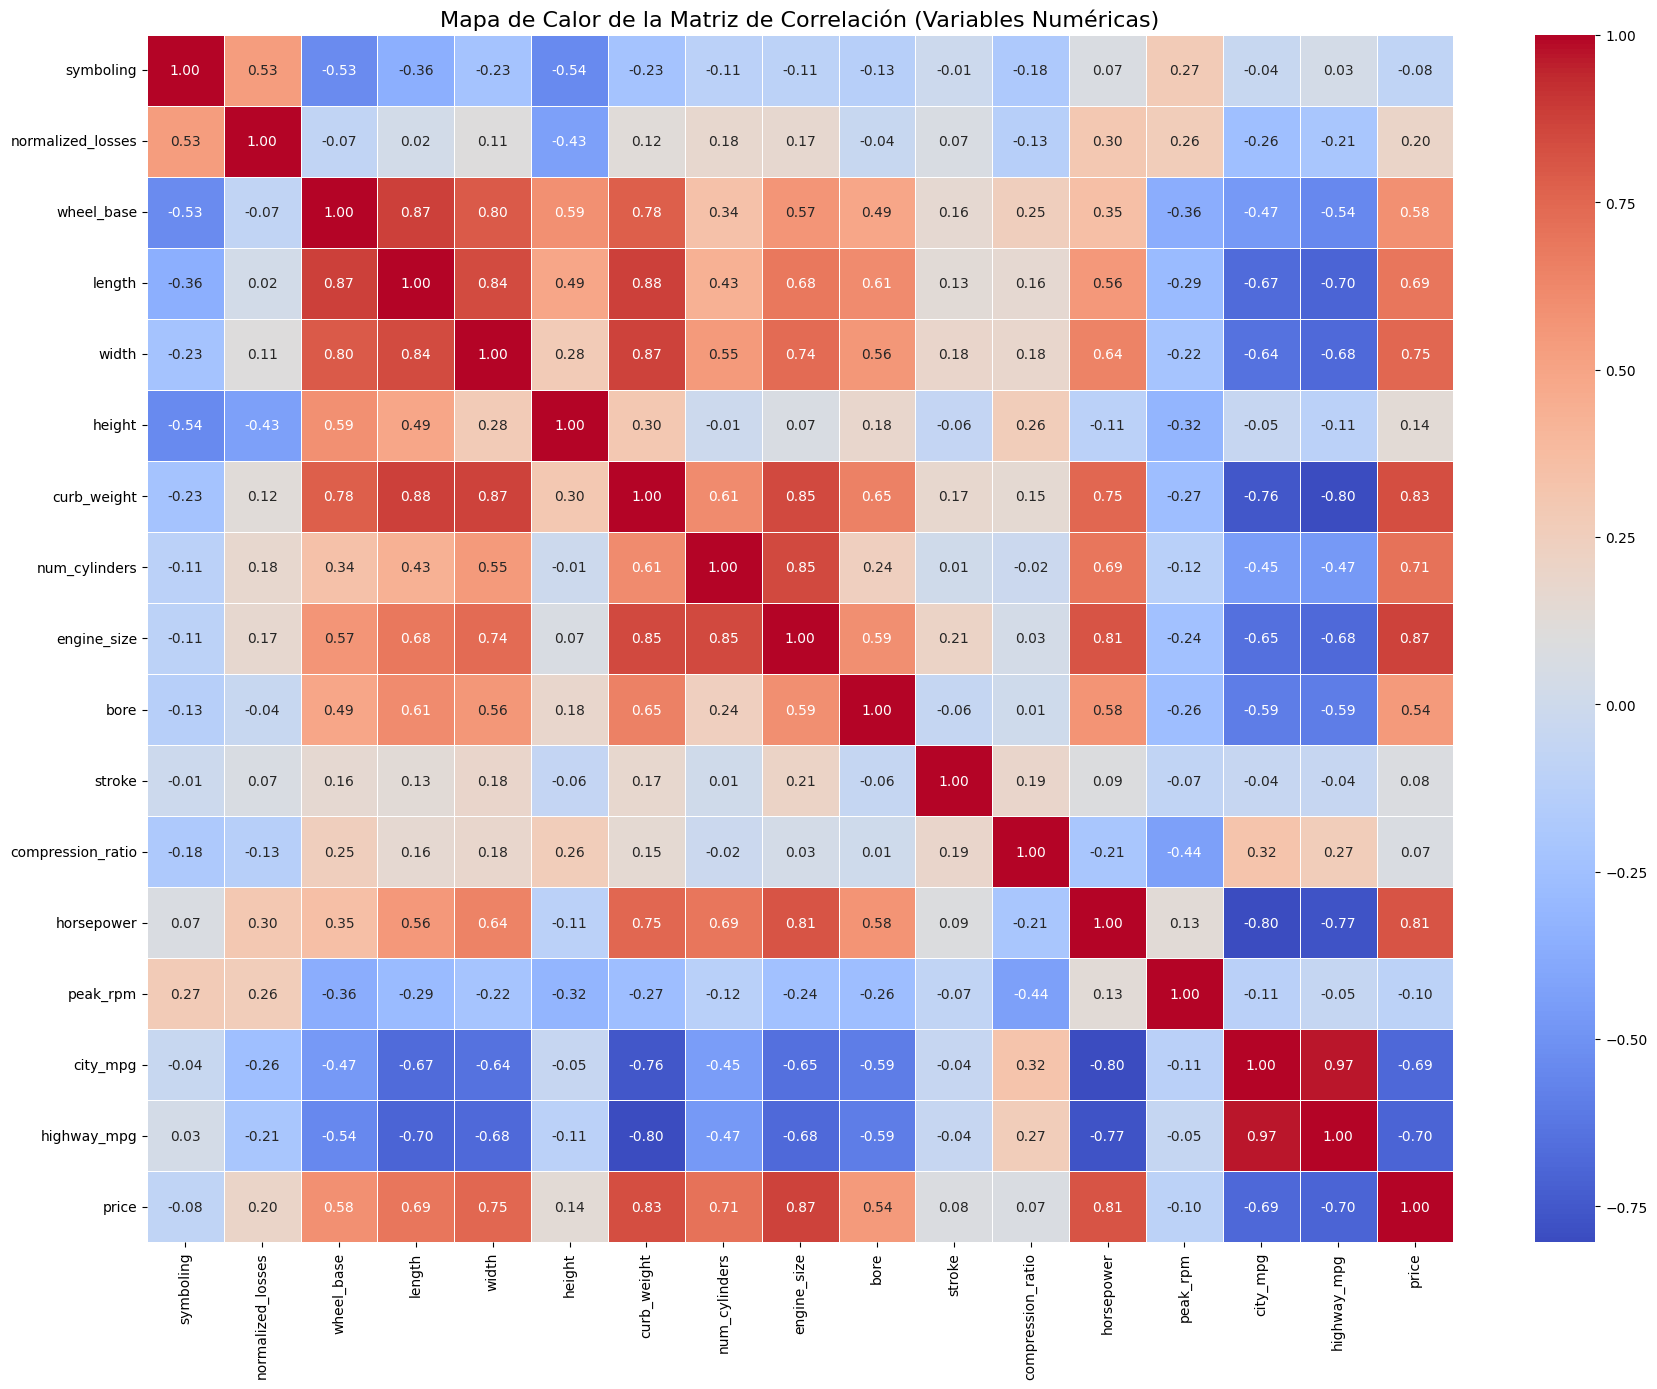

In [10]:
print("Generando Gráfico 5: Mapa de Calor de Correlación...")

df_numeric = cars_df.select_dtypes(include=np.number)
corr_matrix = df_numeric.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Mapa de Calor de la Matriz de Correlación (Variables Numéricas)', fontsize=16)
plt.tight_layout()

print("\n--- Top 3 Variables Más Correlacionadas con 'price' ---")
price_correlations = corr_matrix['price'].sort_values(ascending=False)
top_3_corr = price_correlations[1:4]

print(top_3_corr)

En el análisis de correlación se observa que existen muchos pares de variables altamente correlacionadas, lo que puede afectar el desempeño de los modelos de regresión. PCA resulta útil no solo para reducir la dimensionalidad, sino también porque los componentes principales son ortogonales entre sí, es decir, tienen correlación cero, evitando problemas de multicolinealidad. Esto lo podrás comprobrar más adelante.

# Ingeniería de características

5. Realiza las siguientes operaciones de ingeniería de características en las variables numéricas:
* Aplica `SimpleImputer` para tratar los valores faltantes, justificando la estrategia de imputación seleccionada.
* Considera `price` como la variable objetivo y guárdala en `y`. Separa los predictores numéricos en `X`. Con base en estos datos, ¿cuántos componentes principales se generarán al aplicar PCA?

# **Usamos 'median' porque, como vimos en el EDA, variables como 'price' y 'horsepower' son asimétricas (sesgadas) y tienen valores atípicos. La mediana es robusta a estos valores extremos, mientras que la media ('mean') se vería distorsionada.**


* Escala los valores de `X` para que todas las variables contribuyan equitativamente y ninguna domine el análisis por tener una escala mayor.

PCA está diseñado principalmente para variables numéricas y funciona encontrando combinaciones lineales de las variables originales que capturan la mayor varianza en los datos. Normalmente se recomienda eliminar las variables categóricas antes de aplicar PCA y luego concatenarlas nuevamente con los resultados de PCA si se desea.

In [11]:

print("\n--- 5a. Imputando valores faltantes (SimpleImputer) ---")
numeric_cols = cars_df.select_dtypes(include=np.number).columns
categorical_cols = cars_df.select_dtypes(include='object').columns
imputer_median = SimpleImputer(strategy='median')

imputed_numeric_array = imputer_median.fit_transform(cars_df[numeric_cols])
df_numeric_imputed = pd.DataFrame(
    imputed_numeric_array,
    columns=numeric_cols,
    index=cars_df.index
)

cars_df_imputed = pd.concat([df_numeric_imputed, cars_df[categorical_cols]], axis=1)
print("Imputación con estrategia 'median' completada.")

print("\n--- Separando x (predictores) e y (objetivo) ---")

y = cars_df_imputed['price']
x = cars_df_imputed.select_dtypes(include=np.number).drop('price', axis=1)
print(f"Forma de x (predictores): {x.shape}")
print(f"Forma de y (objetivo): {y.shape}")

total_components = x.shape[1]
print(f"\nAl aplicar PCA, se generarán {total_components} componentes principales.")
print("\n--- 5c. Escalando los predictores (x) ---")
escalar = StandardScaler()
x_scaled = escalar.fit_transform(x)
x_cols = x.columns

print("Primeras 5 filas de x_scaled:")
print(x_scaled[0:5])


--- 5a. Imputando valores faltantes (SimpleImputer) ---
Imputación con estrategia 'median' completada.

--- Separando x (predictores) e y (objetivo) ---
Forma de x (predictores): (205, 16)
Forma de y (objetivo): (205,)

Al aplicar PCA, se generarán 16 componentes principales.

--- 5c. Escalando los predictores (x) ---
Primeras 5 filas de x_scaled:
[[ 1.74347043 -0.17650339 -1.6907718  -0.42652147 -0.84478235 -2.0204173
  -0.01456628 -0.35288699  0.07444893  0.52048915 -1.84134525 -0.28834891
   0.17330945 -0.26498274 -0.64655303 -0.54605874]
 [ 1.74347043 -0.17650339 -1.6907718  -0.42652147 -0.84478235 -2.0204173
  -0.01456628 -0.35288699  0.07444893  0.52048915 -1.84134525 -0.28834891
   0.17330945 -0.26498274 -0.64655303 -0.54605874]
 [ 0.133509   -0.17650339 -0.70859588 -0.23151305 -0.19056612 -0.54352748
   0.51488192  1.50203181  0.60404617 -2.40331309  0.68368323 -0.28834891
   1.26376111 -0.26498274 -0.95301169 -0.69162706]
 [ 0.93848971  1.36790124  0.17369775  0.2072559   0.1

6. Aplica `PCA` a los datos escalados para proyectarlos en el nuevo espacio de vectores.
* Asigna nombres descriptivos a los componentes principales en el dataframe resultante, utilizando la convención PC1, PC2, PC3, y así sucesivamente.
* Genera un mapa de calor con la matriz de correlaciones de los componentes principales para verificar que sean independientes entre sí.

--- Datos Proyectados (Primeras 5 filas) ---
         0         1         2         3         4         5         6   \
0 -0.918474 -2.397150 -0.410501  1.416623 -1.822817  1.203190  0.369729   
1 -0.918474 -2.397150 -0.410501  1.416623 -1.822817  1.203190  0.369729   
2  0.634430 -1.372747  0.872496  0.998222  1.834717 -0.774751 -0.515065   
3 -0.361470 -0.919214  0.451578 -1.489124 -0.269938 -0.789900  0.000484   
4  1.172393 -1.794960  0.183773 -1.083812  0.113486 -0.861858 -0.353900   

         7         8         9         10        11        12        13  \
0  0.288788 -1.088415 -0.347735 -0.474581  0.267610 -0.273617  0.362346   
1  0.288788 -1.088415 -0.347735 -0.474581  0.267610 -0.273617  0.362346   
2  1.370499 -1.130802 -1.013703  0.502983  0.657052  0.174955 -0.008520   
3  0.400032  0.293338  0.168137  0.039239 -0.022832 -0.078891 -0.391786   
4  0.870186  0.015429 -0.447054 -0.055376 -0.416053 -0.049431  0.079357   

         14        15  
0  0.185204  0.003853  
1  0.

Text(0.5, 1.0, 'Mapa de Calor de Correlación de los Componentes Principales')

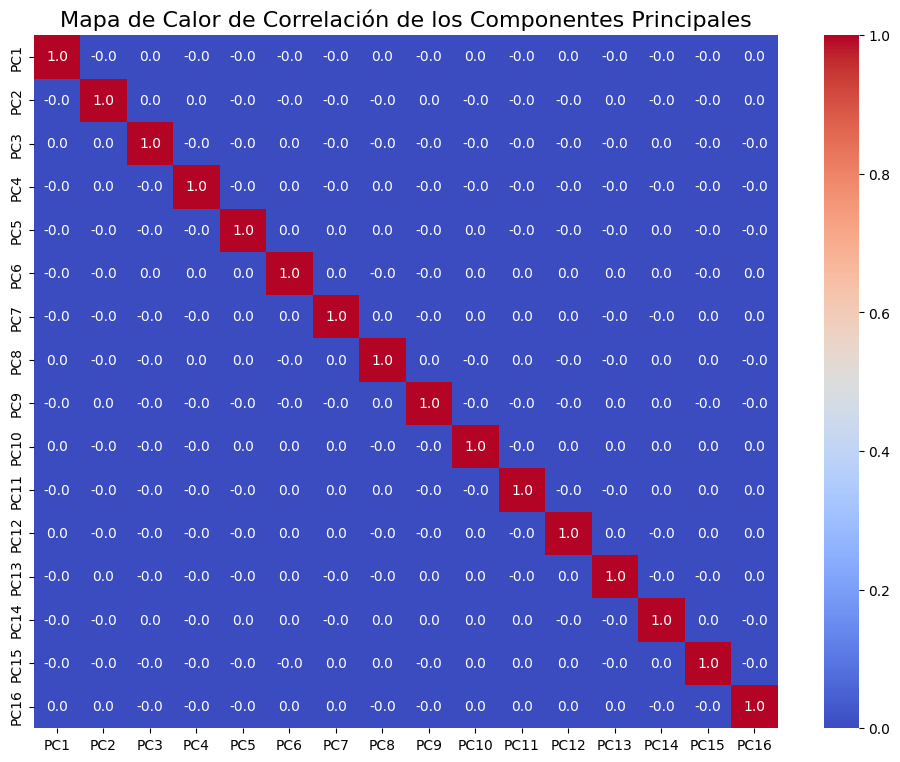

In [12]:
pca = PCA()
x_projected_array = pca.fit_transform(x_scaled)

df_pca = pd.DataFrame(x_projected_array)

print("--- Datos Proyectados (Primeras 5 filas) ---")
print(df_pca.head())


num_components = df_pca.shape[1]
pc_names = [f"PC{i+1}" for i in range(num_components)]
df_pca_named = df_pca.copy()
df_pca_named.columns = pc_names

corr_matrix_pca = df_pca_named.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix_pca,
    annot=True,
    fmt='.1f',
    cmap='coolwarm'
)
plt.title('Mapa de Calor de Correlación de los Componentes Principales', fontsize=16)

7. Obtén el porcentaje de varianza explicada por cada componente.
* Grafica la curva de varianza acumulada para determinar el número mínimo de componentes principales que explican más del 90% de la varianza total.

--- Eigenvalues de la matriz de covarianza ---
[np.float64(7.16297), np.float64(2.88254), np.float64(1.37885), np.float64(1.03494), np.float64(0.92213), np.float64(0.76868), np.float64(0.52265), np.float64(0.43853), np.float64(0.31189), np.float64(0.24993), np.float64(0.12039), np.float64(0.10132), np.float64(0.0828), np.float64(0.0567), np.float64(0.02499), np.float64(0.0191)]

--- Varianza Explicada por Componente ---
  PC1: 44.55%
  PC2: 17.93%
  PC3: 8.58%
  PC4: 6.44%
  PC5: 5.74%
  PC6: 4.78%
  PC7: 3.25%
  PC8: 2.73%
  PC9: 1.94%
  PC10: 1.55%
  PC11: 0.75%
  PC12: 0.63%
  PC13: 0.51%
  PC14: 0.35%
  PC15: 0.16%
  PC16: 0.12%

--- Varianza Acumulada ---
[0.44550204 0.62478221 0.71053978 0.77490828 0.8322602  0.88006862
 0.91257516 0.93984985 0.95924775 0.97479223 0.98227973 0.98858134
 0.99373082 0.9972575  0.99881186 1.        ]

Se necesitan 7 componentes para explicar > 90% de la varianza.


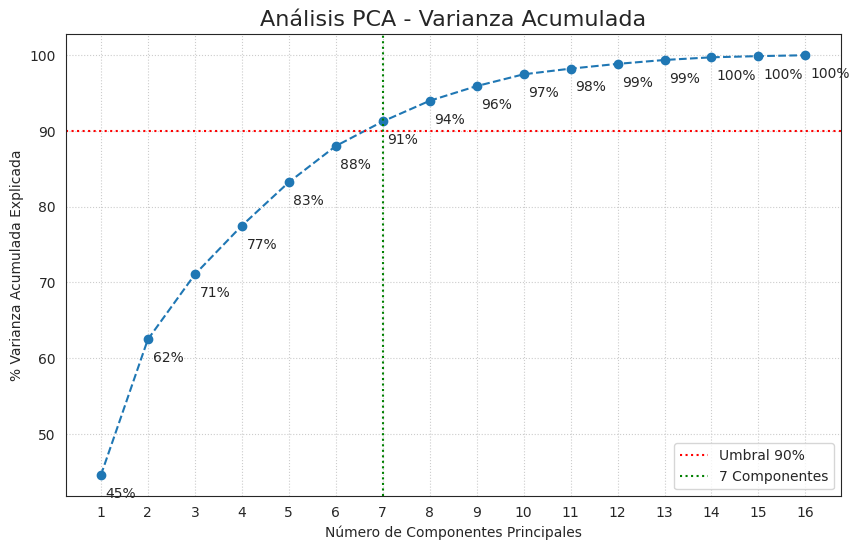

In [13]:
eigenvalues = pca.explained_variance_
print("--- Eigenvalues de la matriz de covarianza ---")
print(list(np.round(eigenvalues, decimals=5)))

explained_variance = pca.explained_variance_ratio_
total_components = len(explained_variance)
print("\n--- Varianza Explicada por Componente ---")
for i in range(0, total_components):
    print(f"  PC{i+1}: {explained_variance[i]:.2%}")

cumulative_variance = np.cumsum(explained_variance)
print("\n--- Varianza Acumulada ---")
print(cumulative_variance)

n_components_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
print(f"\nSe necesitan {n_components_90} componentes para explicar > 90% de la varianza.")

cumulative_variance_pct = cumulative_variance * 100
plt.figure(figsize=(10, 6))
sns.set_style('white')

plt.plot(range(1, total_components + 1), cumulative_variance_pct, marker='o', linestyle='--')
plt.title('Análisis PCA - Varianza Acumulada', fontsize=16)
plt.xlabel('Número de Componentes Principales')
plt.ylabel('% Varianza Acumulada Explicada')
plt.xticks(np.arange(1, total_components + 1, step=1))

for i in range(total_components):
    plt.text(i + 1.1, cumulative_variance_pct[i] - 3, str(format(cumulative_variance_pct[i],'.0f'))+'%')

plt.axhline(y=90, color='r', linestyle=':', label='Umbral 90%')
plt.axvline(x=n_components_90, color='g', linestyle=':', label=f'{n_components_90} Componentes')

plt.legend(loc='lower right')
plt.grid(True, linestyle=':')

8. Imprime la información de los componentes seleccionados (cargas o pesos de las variables originales) para interpretar qué variables contribuyen más a cada componente principal.
* Dibuja un diagrama de barras que muestre qué variables originales aportan más al primer componente principal (PC1), para visualizar su influencia relativa.

--- Cargas Absolutas para los 7 Componentes Seleccionados ---
     symboling  normalized_losses  wheel_base    length     width    height  \
PC1   0.097417           0.015730    0.297827  0.337567  0.334154  0.113918   
PC2   0.402752           0.330804    0.264598  0.138656  0.055178  0.421734   
PC3   0.265425           0.308304    0.029492  0.043866  0.108578  0.282463   
PC4   0.071656           0.343111    0.228250  0.194123  0.097712  0.186128   
PC5   0.365914           0.376068    0.004383  0.073522  0.016414  0.016741   
PC6   0.173471           0.492124    0.183468  0.082219  0.107151  0.214021   
PC7   0.127779           0.322614    0.106348  0.008702  0.139884  0.002597   

     curb_weight  num_cylinders  engine_size      bore    stroke  \
PC1     0.361949       0.245179     0.330140  0.262714  0.052419   
PC2     0.022448       0.114115     0.081608  0.003082  0.034366   
PC3     0.080318       0.176730     0.198927  0.138240  0.511606   
PC4     0.025091       0.552089  

/tmp/ipython-input-1945785202.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


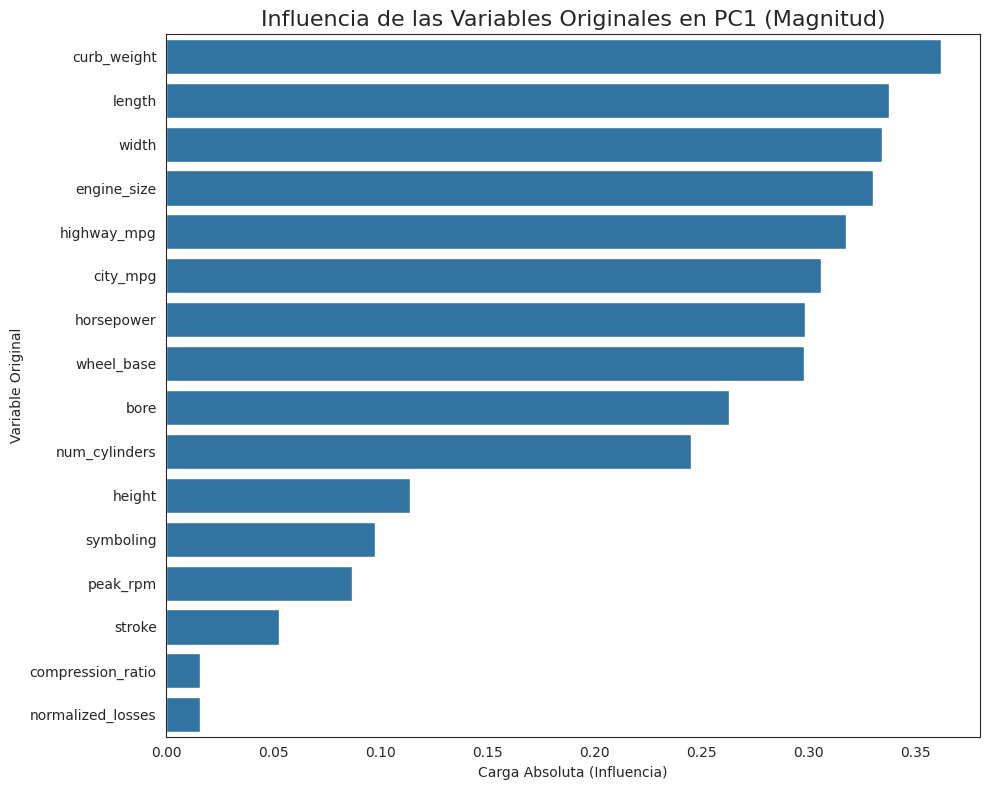

In [14]:
pc_names_selected = [f"PC{i+1}" for i in range(n_components_90)]

df_loadings_abs = pd.DataFrame(
    abs(pca.components_[:n_components_90, :]),
    columns = x_cols,
    index = pc_names_selected
)

print(f"--- Cargas Absolutas para los {n_components_90} Componentes Seleccionados ---")
print(df_loadings_abs)


plt.figure(figsize=(10, 8))
pc1_loadings_sorted = df_loadings_abs.loc['PC1'].sort_values(ascending=False)

sns.barplot(
    x=pc1_loadings_sorted.values,
    y=pc1_loadings_sorted.index,
    ci=None
)
plt.title('Influencia de las Variables Originales en PC1 (Magnitud)', fontsize=16)
plt.xlabel("Carga Absoluta (Influencia)")
plt.ylabel("Variable Original")
plt.tight_layout()

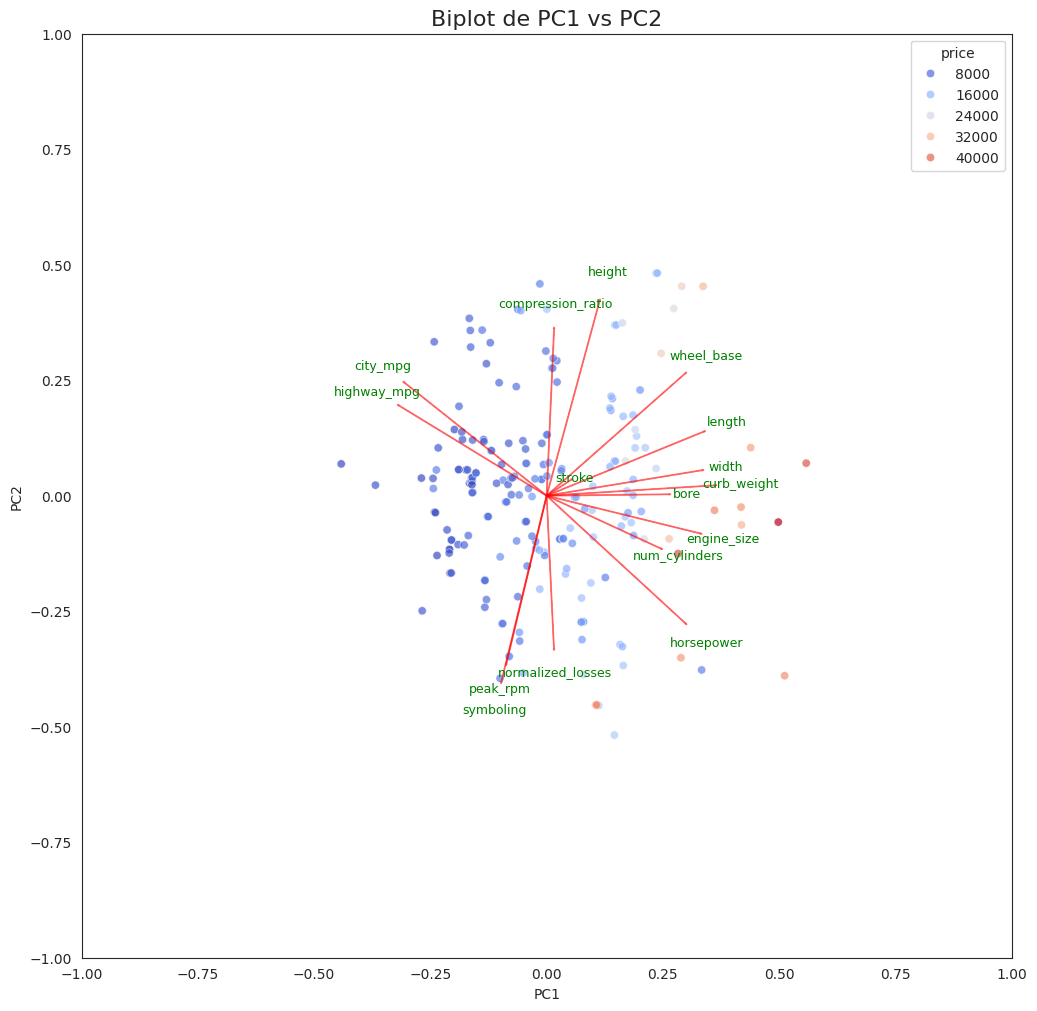

In [15]:
def myplot(score, coeff, labels=None, out=None):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    sns.scatterplot(
        x=xs*scalex, y=ys*scaley,
        hue=out, legend='auto', palette='coolwarm',
        alpha=0.7
    )

    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], color = 'r', alpha = 0.5)
        if labels is None:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color = 'g', ha = 'center', va = 'center')
        else:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center', fontsize=9)

    plt.xlim(-1,1)
    plt.ylim(-1,1)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Biplot de PC1 vs PC2", fontsize=16)
plt.figure(figsize=(12, 12))

scores_pc1_pc2 = np.array(df_pca.iloc[:, 0:2])
loadings_pc1_pc2 = np.transpose(pca.components_[0:2, :])

myplot(scores_pc1_pc2, loadings_pc1_pc2, labels=x_cols, out=y)


9. Codifica las variables categóricas mediante *One-Hot Encoding* y utiliza el parámetro `drop='first'` para evitar problemas de multicolinealidad entre las variables dummy generadas.

In [16]:

df_categorical = cars_df_imputed.select_dtypes(include='object')

print(f"\n--- Codificando {df_categorical.shape[1]} variables categóricas ---")

df_categorical_ohe = pd.get_dummies(
    df_categorical,
    drop_first=True,
    dtype=int
)

print(f"DataFrame OHE creado con {df_categorical_ohe.shape[1]} columnas 'dummy'.")
print(df_categorical_ohe.head())


--- Codificando 9 variables categóricas ---
DataFrame OHE creado con 44 columnas 'dummy'.
   make_audi  make_bmw  make_chevrolet  make_dodge  make_honda  make_isuzu  \
0          0         0               0           0           0           0   
1          0         0               0           0           0           0   
2          0         0               0           0           0           0   
3          1         0               0           0           0           0   
4          1         0               0           0           0           0   

   make_jaguar  make_mazda  make_mercedes-benz  make_mercury  ...  \
0            0           0                   0             0  ...   
1            0           0                   0             0  ...   
2            0           0                   0             0  ...   
3            0           0                   0             0  ...   
4            0           0                   0             0  ...   

   engine_type_ohcf  engi

10. Conjunta, en un dataframe, las valores proyectados en los componentes seleccionados (mínimo), las transformaciones obtenidas de las variables categóricas y la variable de salida.
* Almacena el dataframe resultante en archivo.

In [17]:
print("Conjuntando el DataFrame final...")
print(f"Se usarán los primeros {n_components_90} Componentes Principales.")

# 1. Seleccionar los componentes por POSICIÓN
df_pca_selected = df_pca.iloc[:, 0:n_components_90]
pc_names = [f'PC{i+1}' for i in range(n_components_90)]
df_pca_selected.columns = pc_names

# 3. Conjuntar TODO (PCs + OHE + y)
df_final = pd.concat([
    df_pca_selected,       # Tus 7 PCs
    df_categorical_ohe,    # Tus variables OHE
    y                      # Tu variable 'price'
], axis=1)

# 4. Mostrar y Guardar
print(f"\nDataFrame final creado con {df_final.shape[0]} filas y {df_final.shape[1]} columnas.")
print(df_final.head())

file_name = "final_preprocessed_dataset_v2_example_style.csv"
df_final.to_csv(file_name, index=False)

print(f"\nDataFrame final : {file_name}")


Conjuntando el DataFrame final...
Se usarán los primeros 7 Componentes Principales.

DataFrame final creado con 205 filas y 52 columnas.
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -0.918474 -2.397150 -0.410501  1.416623 -1.822817  1.203190  0.369729   
1 -0.918474 -2.397150 -0.410501  1.416623 -1.822817  1.203190  0.369729   
2  0.634430 -1.372747  0.872496  0.998222  1.834717 -0.774751 -0.515065   
3 -0.361470 -0.919214  0.451578 -1.489124 -0.269938 -0.789900  0.000484   
4  1.172393 -1.794960  0.183773 -1.083812  0.113486 -0.861858 -0.353900   

   make_audi  make_bmw  make_chevrolet  ...  engine_type_ohcv  \
0          0         0               0  ...                 0   
1          0         0               0  ...                 0   
2          0         0               0  ...                 1   
3          1         0               0  ...                 0   
4          1         0               0  ...                 0   

   engine_type_rotor 